In [1]:
from src.dataloading.epiconfig.epiconfig import EpiConfig
from src.dataloading.epidataorchestration.orchestrator import EpiDataOrchestrator
from src.dataloading.dataloaders import DeepDataLoaderManager

cfgde= EpiConfig(
        disease         = 'influenza',
        country         = 'germany',
        level           = 'nuts3',

        min_date        = '2012-06-01',
        max_date        = '2020-06-01',

        horizon_leadtime    = 3,

        feature_popsize         = False,
        feature_popdens         = True,
        feature_gisd            = False,
        feature_popage          = False,
        feature_kreise_classes  = False,
        feature_borders         = False,

        sequence_length     = 4,
        normalization_method='zscore',
        
        log_transform       = ['incidence']     
        )    

dataorchestrator_de   = EpiDataOrchestrator(cfgde).build()
deep_data           = DeepDataLoaderManager(dataorchestrator_de).build()

from src.models import LSTMModel

## Running stuff

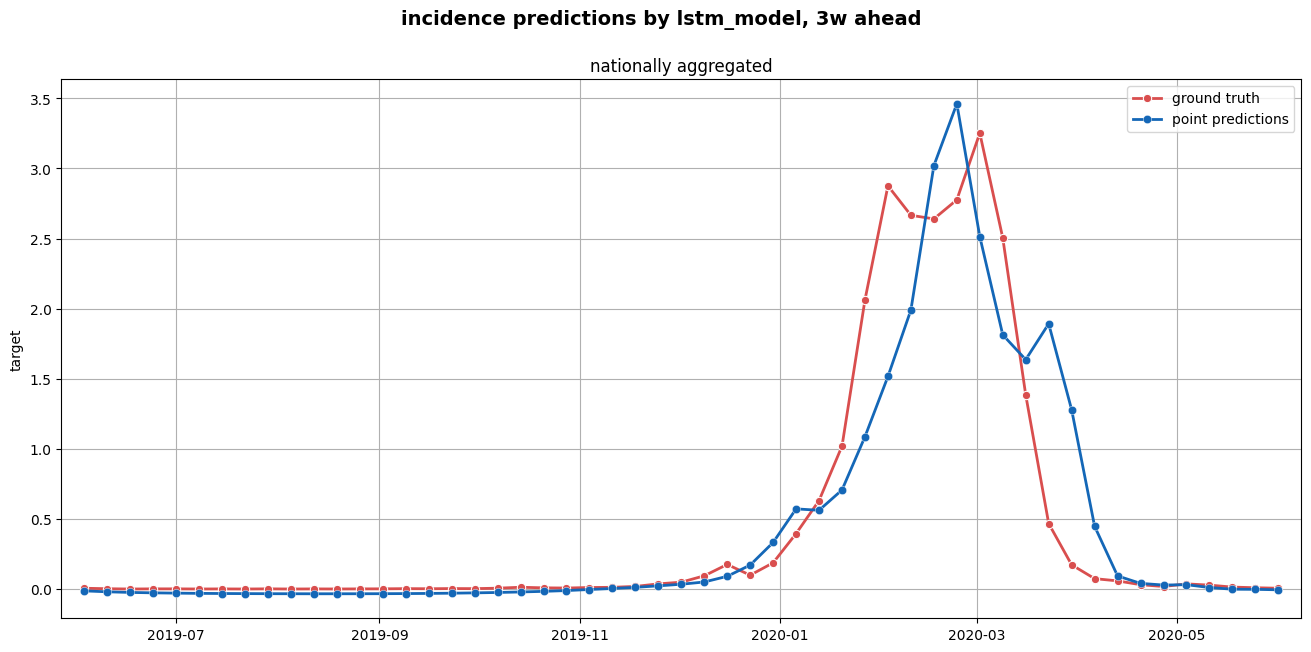

In [2]:
lstm   = LSTMModel(deep_data)
lstm.set_model_hparams()
lstm.set_global_hparams()
lstm.train()
lstm.forecast()
lstm.show_forecasts('national').show()

In [9]:
lstm_ld = lstm.load_model('lstm_hl3_s456', deep_data,'experiment_1_v2')
lstm_ld.forecast()

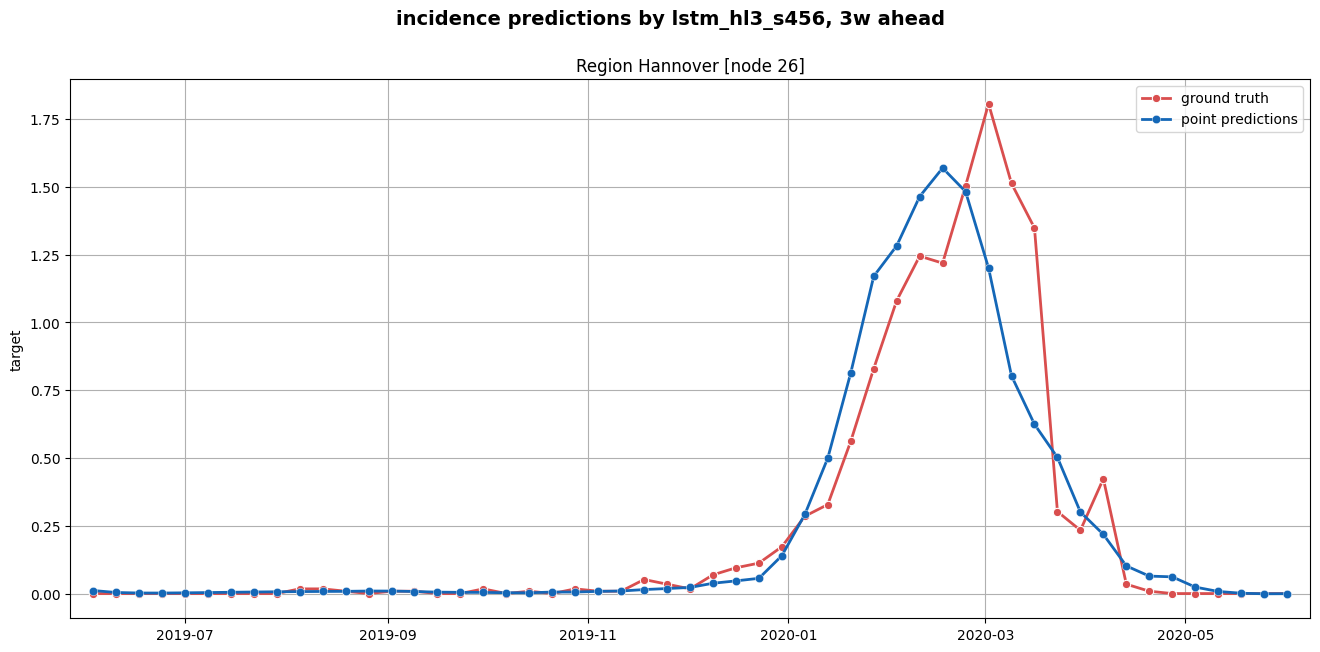

In [11]:
lstm_ld.show_forecasts(26).show()